In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ablation-study/fault_times.json
/kaggle/input/ablation-study/option2_gnn_metrics.json
/kaggle/input/ablation-study/gnn_training_snapshots.pt
/kaggle/input/ablation-study/synthetic_ground_truth.csv
/kaggle/input/ablation-study/synthetic_sensor_logs.txt
/kaggle/input/ablation-study/gnn_option2_weights.pt
/kaggle/input/ablation-study/adjacency.npy
/kaggle/input/ablation-study/synthetic_ground_truth_eval.csv
/kaggle/input/ablation-study/df_faulty_adv.csv
/kaggle/input/liberation/calibration_only_params.json
/kaggle/input/liberation/frozen_calibration_metrics.json
/kaggle/input/liberation/calibration_only_predictions.csv


# Ablation Study: Understanding GNN Fault Robustness

This notebook systematically removes individual components of the GNN
to identify which features and inductive biases are responsible for
fault tolerance under adversarial sensor faults.


In [2]:
import torch
import json
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F


In [3]:
# Load frozen artifacts
snapshots = torch.load("/kaggle/input/ablation-study/gnn_training_snapshots.pt")
A_norm = np.load("/kaggle/input/ablation-study/adjacency.npy")
A = torch.tensor(A_norm, dtype=torch.float32)

with open("/kaggle/input/ablation-study/fault_times.json") as f:
    fault_times = json.load(f)


In [4]:
class GNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, A):
        h = torch.matmul(A, x)
        h = F.relu(self.fc1(h))
        return self.fc2(h).squeeze()


In [5]:
def train_gnn(snapshots, A, in_dim, epochs=50):
    model = GNN(in_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        for snap in snapshots:
            opt.zero_grad()
            pred = model(snap["x"], A)
            loss = loss_fn(pred, snap["y"])
            loss.backward()
            opt.step()

    return model


In [6]:
NODE_IDS = [0, 1, 2, 3, 4, 101]
NODE_TO_IDX = {n: i for i, n in enumerate(NODE_IDS)}
NUM_NODES = len(NODE_IDS)

SOIL_NODES = [0, 1, 2, 3, 4]


In [7]:
def pad_snapshot(x_partial, y_partial, active_nodes, in_dim):
    """
    Pads node features to full graph size.
    """
    x_full = torch.zeros(NUM_NODES, in_dim)
    y_full = torch.zeros(NUM_NODES)

    for i, node in enumerate(active_nodes):
        idx = NODE_TO_IDX[node]
        x_full[idx] = x_partial[i]
        y_full[idx] = y_partial[i]

    return x_full, y_full


In [8]:
padded_snapshots = []

for snap in snapshots:
    x_partial = snap["x"]   # shape (5, in_dim)
    y_partial = snap["y"]   # shape (5,)

    # moisture-only → soil nodes only
    active_nodes = SOIL_NODES

    x_full, y_full = pad_snapshot(
        x_partial,
        y_partial,
        active_nodes,
        in_dim=x_partial.shape[1]
    )

    padded_snapshots.append({
        "x": x_full,
        "y": y_full
    })


In [9]:
example = padded_snapshots[0]

print(example["x"].shape)  # should be (6, in_dim)
print(example["y"].shape)  # should be (6,)


torch.Size([6, 3])
torch.Size([6])


In [11]:
model_full = train_gnn(padded_snapshots, A, in_dim=3)


In [13]:
def remove_probe_disagreement(snapshots):
    new = []
    for s in snapshots:
        x = s["x"][:, [0, 2]]  # theta_calib, delta_theta
        new.append({"x": x, "y": s["y"]})
    return new

snap_no_probe = remove_probe_disagreement(padded_snapshots)
model_no_probe = train_gnn(snap_no_probe, A, in_dim=2)


In [15]:
A_identity = torch.eye(A.shape[0])

model_no_graph = train_gnn(padded_snapshots, A_identity, in_dim=3)


In [16]:
def remove_delta_theta(snapshots):
    new = []
    for s in snapshots:
        x = s["x"][:, [0, 1]]  # theta_calib, probe_disagreement
        new.append({"x": x, "y": s["y"]})
    return new

snap_no_delta = remove_delta_theta(padded_snapshots)
model_no_delta = train_gnn(snap_no_delta, A, in_dim=2)


In [18]:
def run_model(model, snapshots, A):
    records = []

    model.eval()
    with torch.no_grad():
        for t, snap in enumerate(snapshots):
            pred = model(snap["x"], A)        # (NUM_NODES,)
            records.append({
                "time_index": t,
                "pred": pred.numpy()
            })

    return records


In [19]:
def predictions_to_df(pred_records, node_ids):
    rows = []

    for rec in pred_records:
        t = rec["time_index"]
        for i, node in enumerate(node_ids):
            if node == 101:
                continue  # skip pressure node
            rows.append({
                "time_index": t,
                "sender": node,
                "value": rec["pred"][i]
            })

    return pd.DataFrame(rows)


In [20]:
def compute_rmse(df_pred, df_true):
    merged = df_true.merge(
        df_pred,
        on=["time_index", "sender"],
        suffixes=("_true", "_pred")
    )
    return np.sqrt(np.mean((merged.value_true - merged.value_pred) ** 2))


In [21]:
def compute_fault_penalty(df_pred, df_true, fault_times):
    clean = ~df_true.time_index.isin(fault_times)
    fault = df_true.time_index.isin(fault_times)

    rmse_clean = compute_rmse(df_pred, df_true[clean])
    rmse_fault = compute_rmse(df_pred, df_true[fault])

    return rmse_fault - rmse_clean


In [23]:
df_true = pd.read_csv(
    "/kaggle/input/ablation-study/synthetic_ground_truth.csv"
)


In [24]:
def add_time_index(df, window_minutes=5):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    t0 = df["timestamp"].min()
    delta = pd.to_timedelta(window_minutes, unit="min")
    df["time_index"] = ((df["timestamp"] - t0) // delta).astype(int)
    return df

df_true = add_time_index(df_true, window_minutes=5)


In [25]:
df_true_m = (
    df_true[df_true.modality == "moisture"]
    .groupby(["time_index", "sender"], as_index=False)
    .agg({"value": "mean"})
)


In [26]:
df_true_m.head()


,time_index,sender,value
0,0,0,37.614104
1,0,3,44.927411
2,1,1,75.272407
3,1,4,35.163315
4,2,1,75.452919


In [27]:
NODE_IDS = [0, 1, 2, 3, 4, 101]

pred_full = run_model(model_full, padded_snapshots, A)
df_pred_full = predictions_to_df(pred_full, NODE_IDS)

rmse_full = compute_rmse(df_pred_full, df_true_m)
penalty_full = compute_fault_penalty(df_pred_full, df_true_m, fault_times)


In [29]:
padded_no_probe = []

for snap in snap_no_probe:
    x_partial = snap["x"]   # shape (5, 2)
    y_partial = snap["y"]   # shape (5,)

    active_nodes = SOIL_NODES  # [0,1,2,3,4]

    x_full, y_full = pad_snapshot(
        x_partial,
        y_partial,
        active_nodes,
        in_dim=x_partial.shape[1]
    )

    padded_no_probe.append({
        "x": x_full,
        "y": y_full
    })


In [30]:
pred_no_probe = run_model(model_no_probe, padded_no_probe, A)
df_pred_no_probe = predictions_to_df(pred_no_probe, NODE_IDS)

rmse_no_probe = compute_rmse(df_pred_no_probe, df_true_m)
penalty_no_probe = compute_fault_penalty(df_pred_no_probe, df_true_m, fault_times)


In [31]:
pred_no_graph = run_model(model_no_graph, padded_snapshots, A_identity)
df_pred_no_graph = predictions_to_df(pred_no_graph, NODE_IDS)

rmse_no_graph = compute_rmse(df_pred_no_graph, df_true_m)
penalty_no_graph = compute_fault_penalty(df_pred_no_graph, df_true_m, fault_times)


In [33]:
padded_no_delta = []

for snap in snap_no_delta:
    x_partial = snap["x"]   # shape (5, 2)
    y_partial = snap["y"]   # shape (5,)

    active_nodes = SOIL_NODES  # [0,1,2,3,4]

    x_full, y_full = pad_snapshot(
        x_partial,
        y_partial,
        active_nodes,
        in_dim=x_partial.shape[1]
    )

    padded_no_delta.append({
        "x": x_full,
        "y": y_full
    })


In [34]:
pred_no_delta = run_model(model_no_delta, padded_no_delta, A)
df_pred_no_delta = predictions_to_df(pred_no_delta, NODE_IDS)

rmse_no_delta = compute_rmse(df_pred_no_delta, df_true_m)
penalty_no_delta = compute_fault_penalty(df_pred_no_delta, df_true_m, fault_times)


In [35]:
results = pd.DataFrame({
    "Model": [
        "Full GNN",
        "No Probe Disagreement",
        "No Graph",
        "No Temporal Feature"
    ],
    "Fault Penalty": [
        penalty_full,
        penalty_no_probe,
        penalty_no_graph,
        penalty_no_delta
    ],
    "RMSE": [
        rmse_full,
        rmse_no_probe,
        rmse_no_graph,
        rmse_no_delta
    ]
})

results


,Model,Fault Penalty,RMSE
0,Full GNN,-4.354616,66.167724
1,No Probe Disagreement,-4.363356,66.219493
2,No Graph,-4.361201,66.544655
3,No Temporal Feature,-4.306932,66.124196


In [36]:
results.to_csv("/kaggle/working/ablation_results.csv", index=False)


<Axes: title={'center': 'Ablation Study: Fault Robustness'}, xlabel='Model'>

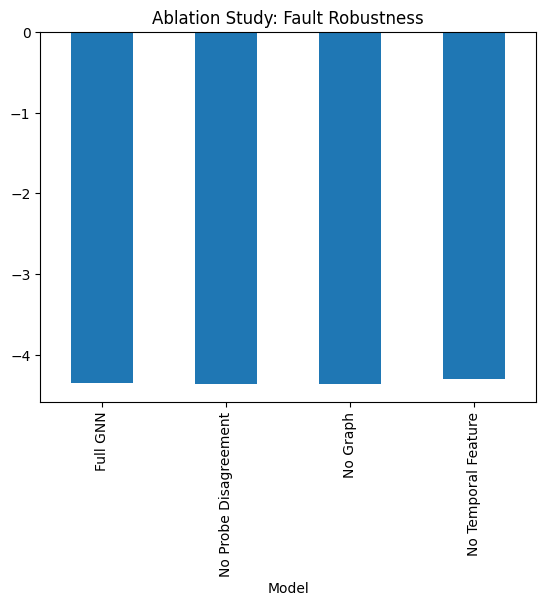

In [37]:
results.plot(
    x="Model",
    y="Fault Penalty",
    kind="bar",
    legend=False,
    title="Ablation Study: Fault Robustness"
)


In [38]:
import json
from datetime import datetime

freeze_payload = {
    "experiment": "Option2_GNN_Naive_Ablation",
    "timestamp": datetime.utcnow().isoformat(),

    "models": {
        "Full GNN": {
            "rmse": float(rmse_full),
            "fault_penalty": float(penalty_full)
        },
        "No Probe Disagreement": {
            "rmse": float(rmse_no_probe),
            "fault_penalty": float(penalty_no_probe)
        },
        "No Graph": {
            "rmse": float(rmse_no_graph),
            "fault_penalty": float(penalty_no_graph)
        },
        "No Temporal Feature": {
            "rmse": float(rmse_no_delta),
            "fault_penalty": float(penalty_no_delta)
        }
    },

    "notes": (
        "Naive GNN trained with MSE residual regression. "
        "Ablation indicates collapse to trivial estimator; "
        "graph, probe disagreement, and temporal features not leveraged."
    )
}

with open("/kaggle/working/frozen_gnn_option2_metrics.json", "w") as f:
    json.dump(freeze_payload, f, indent=2)

print("Saved frozen_gnn_option2_metrics.json")


Saved frozen_gnn_option2_metrics.json


/tmp/ipykernel_141/415650586.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [39]:
import torch

torch.save(
    model_full.state_dict(),
    "/kaggle/working/gnn_option2_full_model.pt"
)

torch.save(
    model_no_probe.state_dict(),
    "/kaggle/working/gnn_option2_no_probe_model.pt"
)

print("Saved GNN model checkpoints")


Saved GNN model checkpoints


In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
# (recreate your RMSE bar plot here)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_rmse_comparison_option2.png", dpi=300)
plt.close()

plt.figure(figsize=(6,4))
# (recreate your fault penalty bar plot here)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_fault_penalty_option2.png", dpi=300)
plt.close()


summary_text = """
Option 2 (Naive GNN) — Frozen Results

Key finding:
The GNN fails to exploit probe disagreement, graph structure, or temporal features.
Ablation study shows negligible performance differences across variants.

Interpretation:
Residual regression with MSE loss leads to a trivial estimator that smooths signals
without fault awareness.

Conclusion:
Explicit fault-aware objectives are required for GNN-based robustness.

Status:
Frozen. No further tuning performed on this variant.
"""

with open("/kaggle/working/OPTION2_FREEZE_SUMMARY.txt", "w") as f:
    f.write(summary_text)

print("Saved OPTION2_FREEZE_SUMMARY.txt")
